## Uber
Uber is a global ride-hailing service founded in 2009, revolutionizing urban transportation by allowing users to book rides via a mobile app. It connects passengers with drivers of vehicles for hire, offering a convenient, on-demand service. Uber operates in hundreds of cities worldwide, providing various services, including UberX (standard rides), UberPOOL (shared rides), and UberBLACK (luxury rides). In addition to ride-hailing, Uber has expanded into food delivery (Uber Eats) and freight logistics (Uber Freight). Known for its user-friendly app and cashless transactions, Uber has transformed how people move within cities.

## Uber Travel Analysis
The Uber Travel Analysis Project aims to explore and understand user travel patterns through Uber's services. Leveraging a comprehensive dashboard, this project analyzes various aspects of Uber trips, including trip categories, peak travel hours, trip purposes, distances covered, and the busiest days and months. The analysis also investigates the most popular starting locations for Uber rides, providing a clear picture of where demand is highest.

By visualizing these data points, the project offers insights into user behavior, such as when people are most likely to take Uber, the motivations behind their trips, and the typical distances they travel. These insights can help Uber optimize its operations, ensuring better resource allocation during peak periods and improving service quality in high-demand areas. Ultimately, this project provides a data-driven perspective on Uber travel trends, supporting decision-making for both service providers and stakeholders.


### Objectives
 1. Check how long people travel with uber ?
 2. What hour do most people take uber to their destination?
 3. Check the purpose of the trips?
 4. Which Day has the highest number of trips?
 5. What are the trips in the month?
 6. The starting point of trips. Where do people start bording their trip from the most?

In [1]:
# Importing libs
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime 
import calendar

In [3]:
# Loading our data set
data = pd.read_csv("Uber Drives - .csv")

In [4]:
data.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,1/1/2016 21:11,1/1/2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,1/2/2016 1:25,1/2/2016 1:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,1/2/2016 20:25,1/2/2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,1/5/2016 17:31,1/5/2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,1/6/2016 14:42,1/6/2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [5]:
data.shape

(1156, 7)

In [8]:
# Cheacking for missing values
data.isnull().sum()

START_DATE*    0
END_DATE*      0
CATEGORY*      0
START*         0
STOP*          0
MILES*         0
PURPOSE*       0
dtype: int64

In [7]:
data = data.dropna()

In [10]:
data.shape

(653, 7)

In [12]:
data.dtypes

START_DATE*     object
END_DATE*       object
CATEGORY*       object
START*          object
STOP*           object
MILES*         float64
PURPOSE*        object
dtype: object

In [17]:
# converting start_date and end_date from 'object' to datetime
data['START_DATE*'] = pd.to_datetime(data['START_DATE*'], format = '%m/%d/%Y %H:%M')
data['END_DATE*'] = pd.to_datetime(data['END_DATE*'], format = '%m/%d/%Y %H:%M')

In [19]:
data.dtypes

START_DATE*    datetime64[ns]
END_DATE*      datetime64[ns]
CATEGORY*              object
START*                 object
STOP*                  object
MILES*                float64
PURPOSE*               object
dtype: object

In [20]:
data.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
5,2016-01-06 17:15:00,2016-01-06 17:19:00,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain


In [22]:
hour = []
day = []
dayofweek = []
month = []
weekday = []

for x in data["START_DATE*"]:
    hour.append(x.hour)
    day.append(x.day)
    dayofweek.append(x.dayofweek)
    month.append(x.month)
    weekday.append(calendar.day_name[dayofweek[-1]])


# Creating columns
data["Hour"] = hour
data["Day"] = day
data["Day_of_week"] = dayofweek
data["Month"] = month
data["Week_day"] = weekday

In [23]:
data.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*,Hour,Day,Day_of_week,Month,Week_day
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21,1,4,1,Friday
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,20,2,5,1,Saturday
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,17,5,1,1,Tuesday
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,14,6,2,1,Wednesday
5,2016-01-06 17:15:00,2016-01-06 17:19:00,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain,17,6,2,1,Wednesday


### EDA : Exploratory Data Analysis

In [24]:
data["CATEGORY*"].value_counts()

CATEGORY*
Business    647
Personal      6
Name: count, dtype: int64

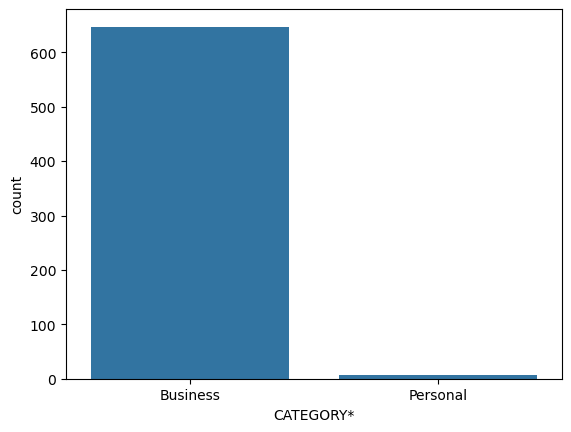

In [26]:
# showing the visuals of category
sns.countplot(x = "CATEGORY*", data = data);

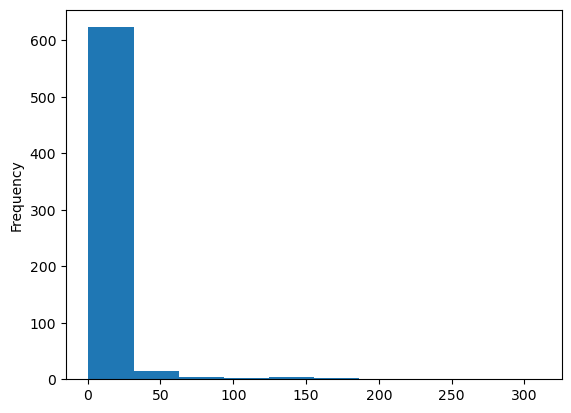

In [28]:
# OBJ 1: How long people travel with uber ?
data["MILES*"].plot.hist();

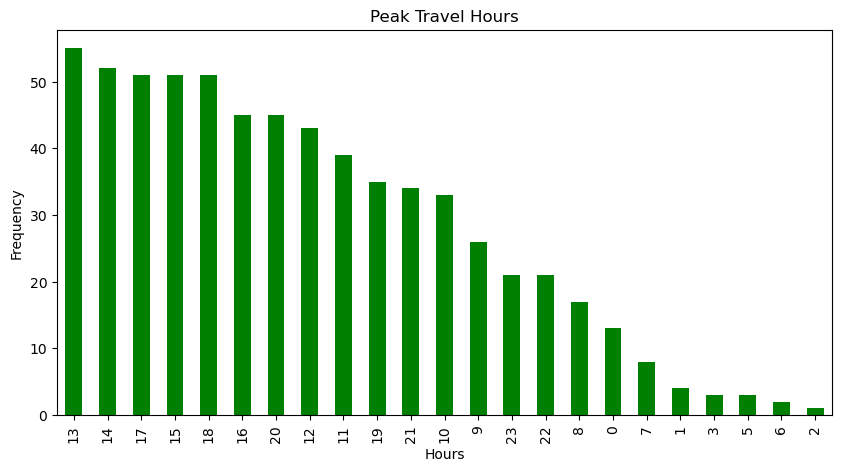

In [31]:
# OBJ 2 : What hour do most people take uber to their destination?
hours = data["START_DATE*"].dt.hour.value_counts()
hours.plot(kind = "bar", color = "green", figsize = (10, 5))

plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.title("Peak Travel Hours");

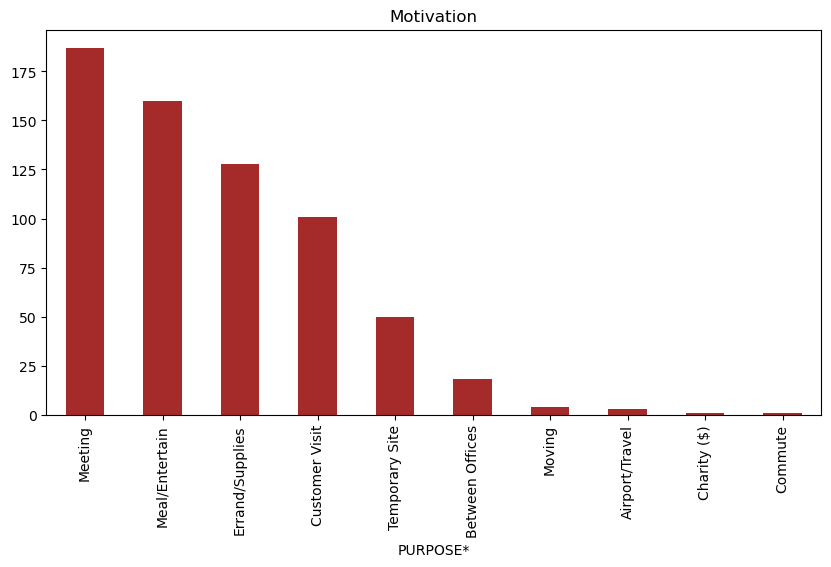

In [32]:
# OBJ 3: The purpose of the trips?
data["PURPOSE*"].value_counts().plot(kind = "bar", color = "brown", figsize = (10, 5))
plt.title("Motivation");

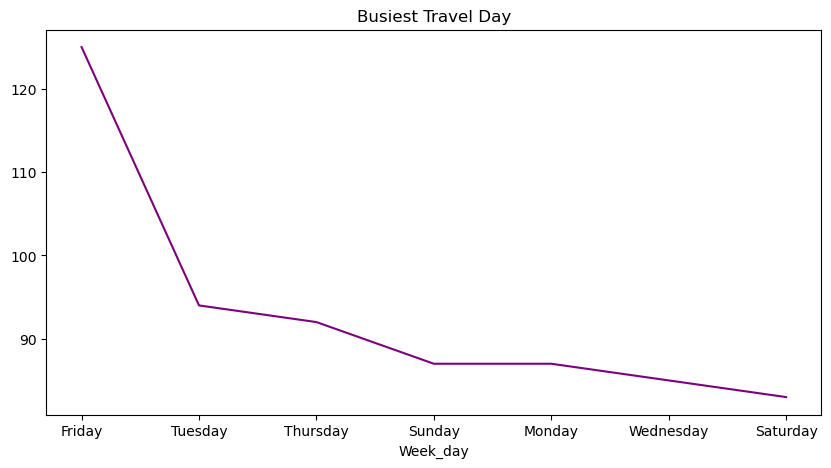

In [34]:
# OBJ 4: Which Day has the highest number of trips?
data["Week_day"].value_counts().plot(kind = "line", color = "purple", figsize = (10, 5))
plt.title("Busiest Travel Day");

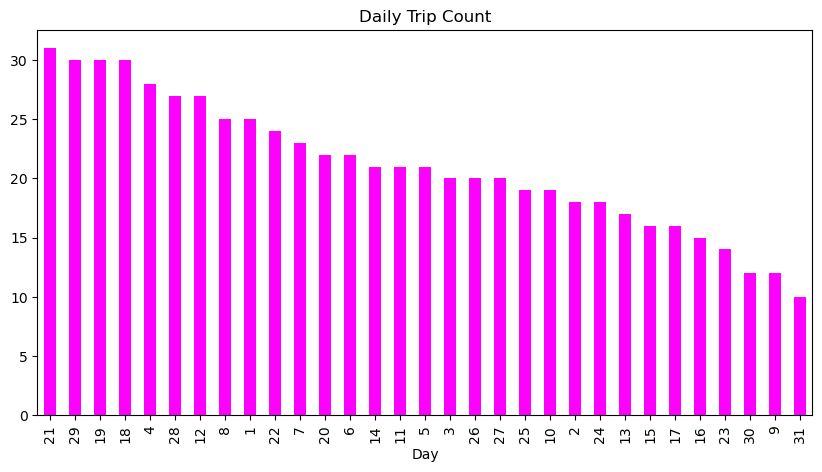

In [36]:
# OBJ 5: What are the number trips per each day?
data["Day"].value_counts().plot(kind = "bar", color = "magenta", figsize = (10, 5))
plt.title("Daily Trip Count");

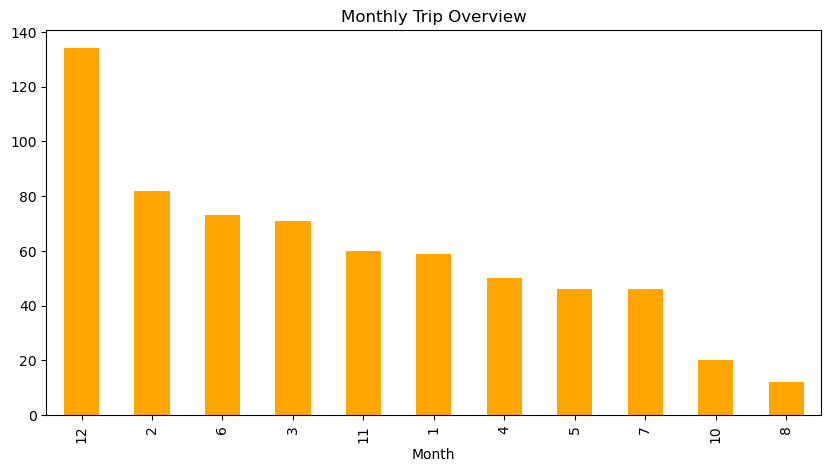

In [37]:
# OBJ 6: What are the trips in the month?
data["Month"].value_counts().plot(kind = "bar", color = "orange", figsize = (10, 5))
plt.title("Monthly Trip Overview");

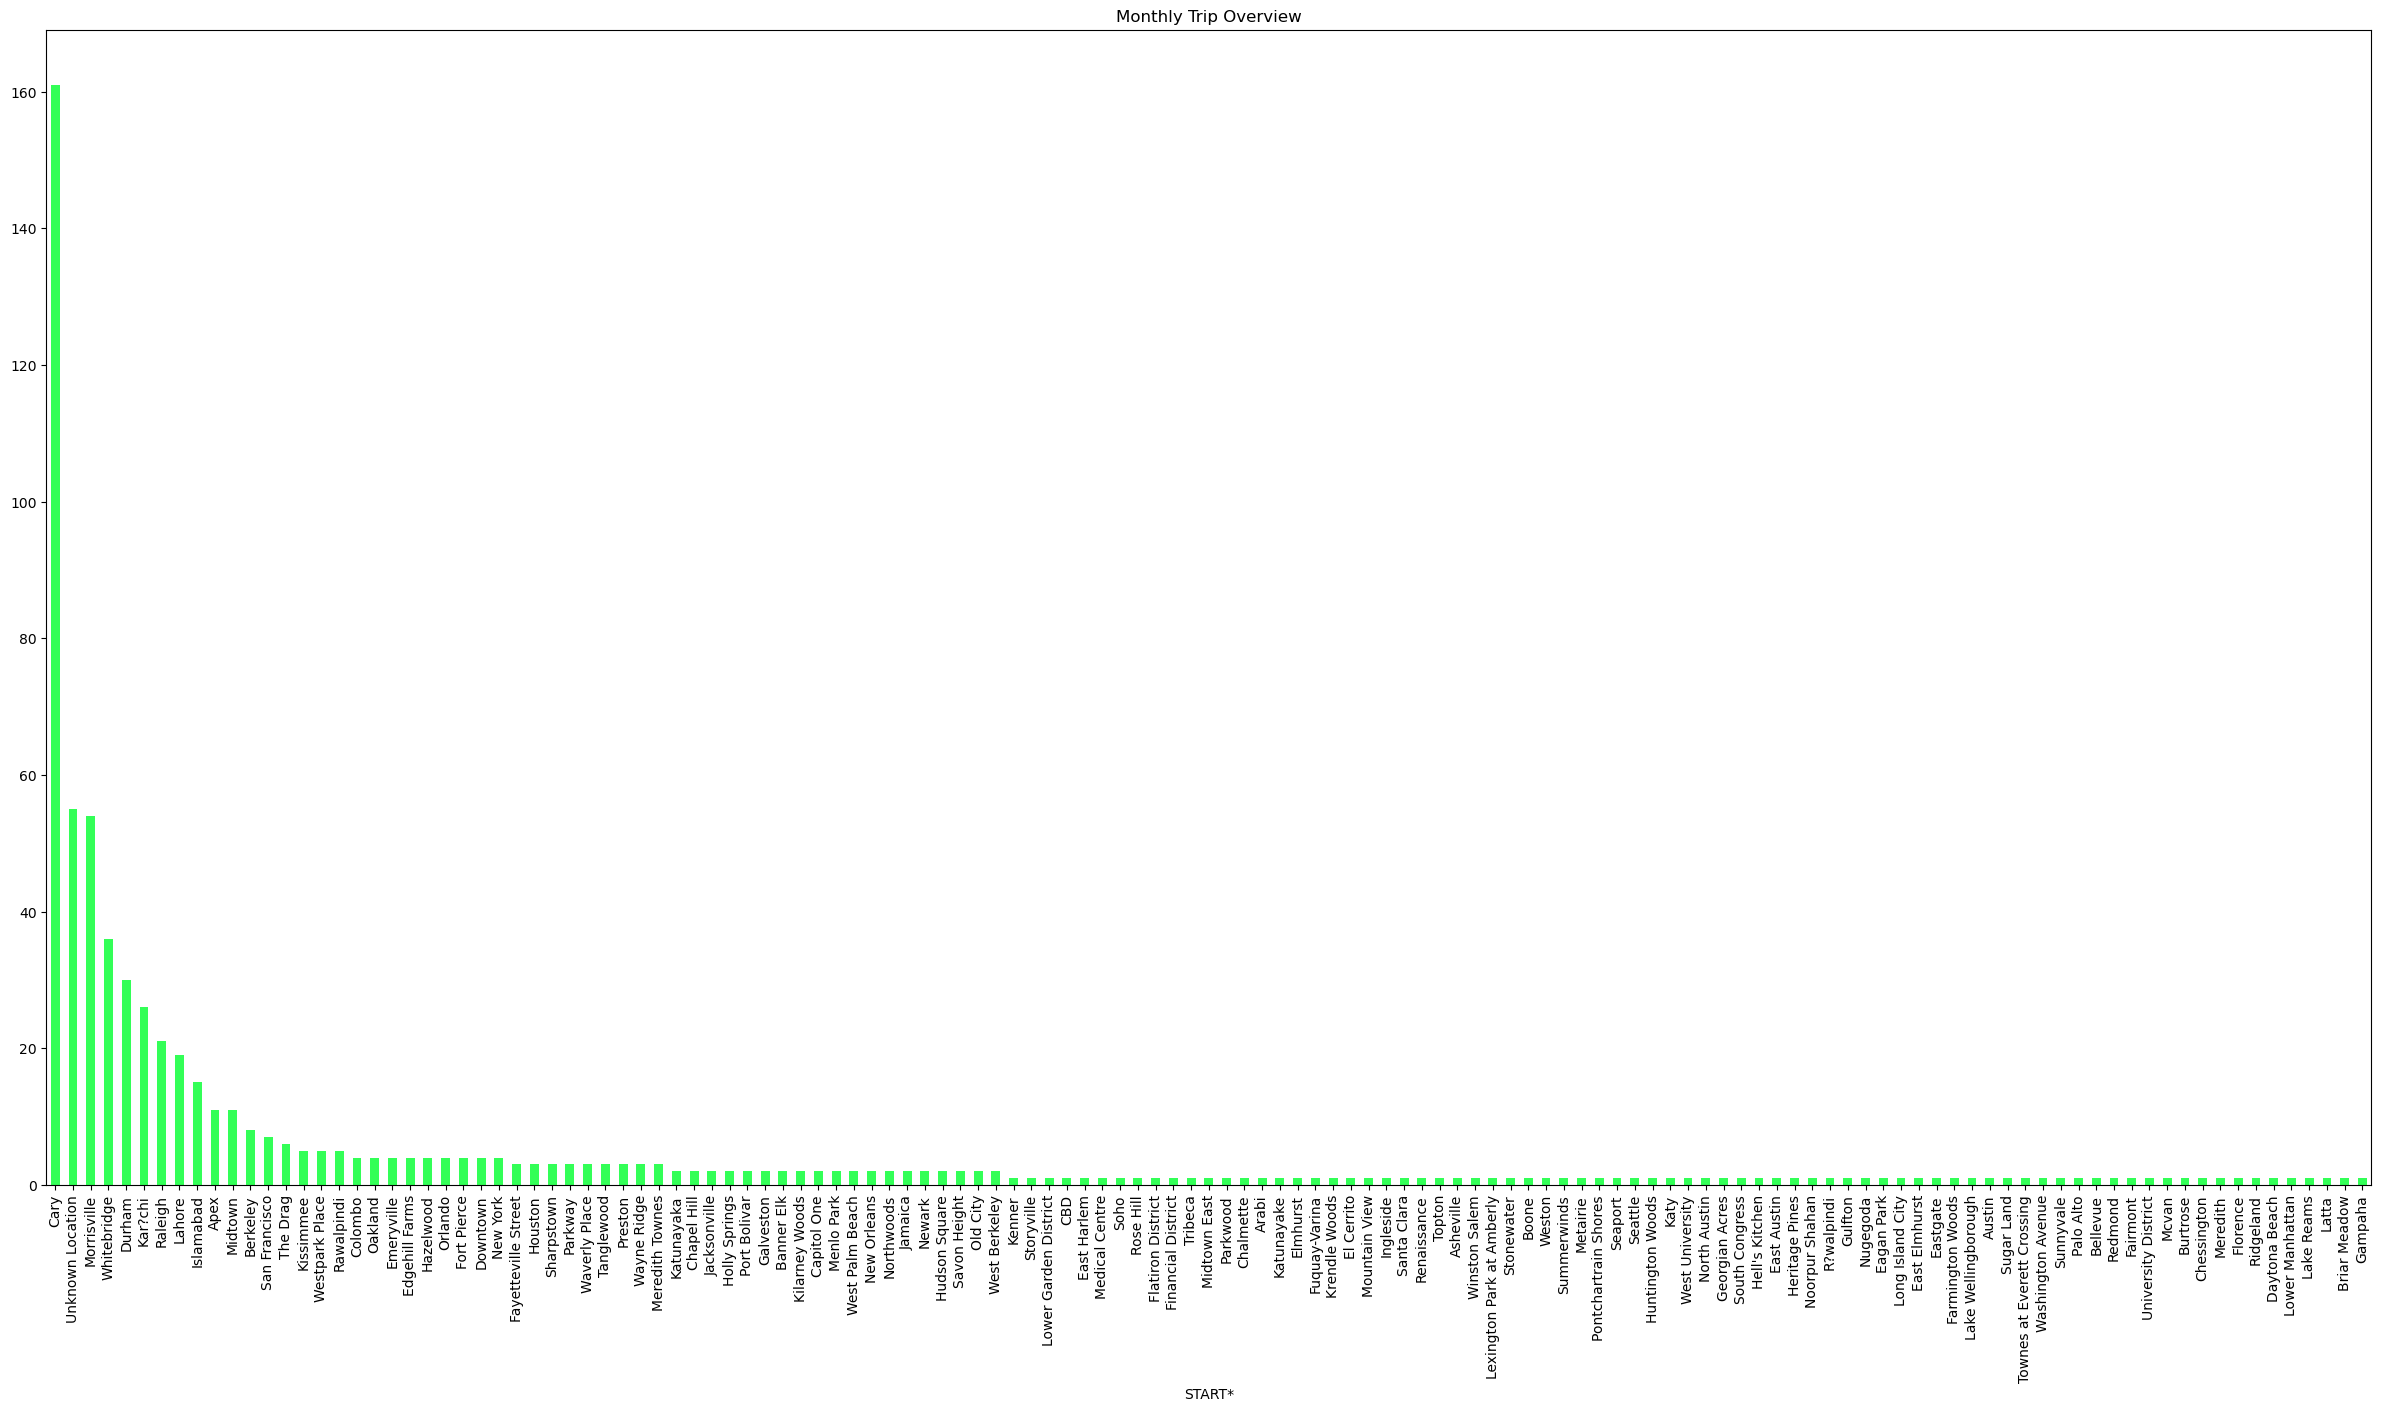

In [38]:
# OBJ 7:The starting point of trips. Where do people start bording their trip from the most?
data["START*"].value_counts().plot(kind = "bar", color = "#33FF57", figsize = (30, 15))
plt.title("Monthly Trip Overview");

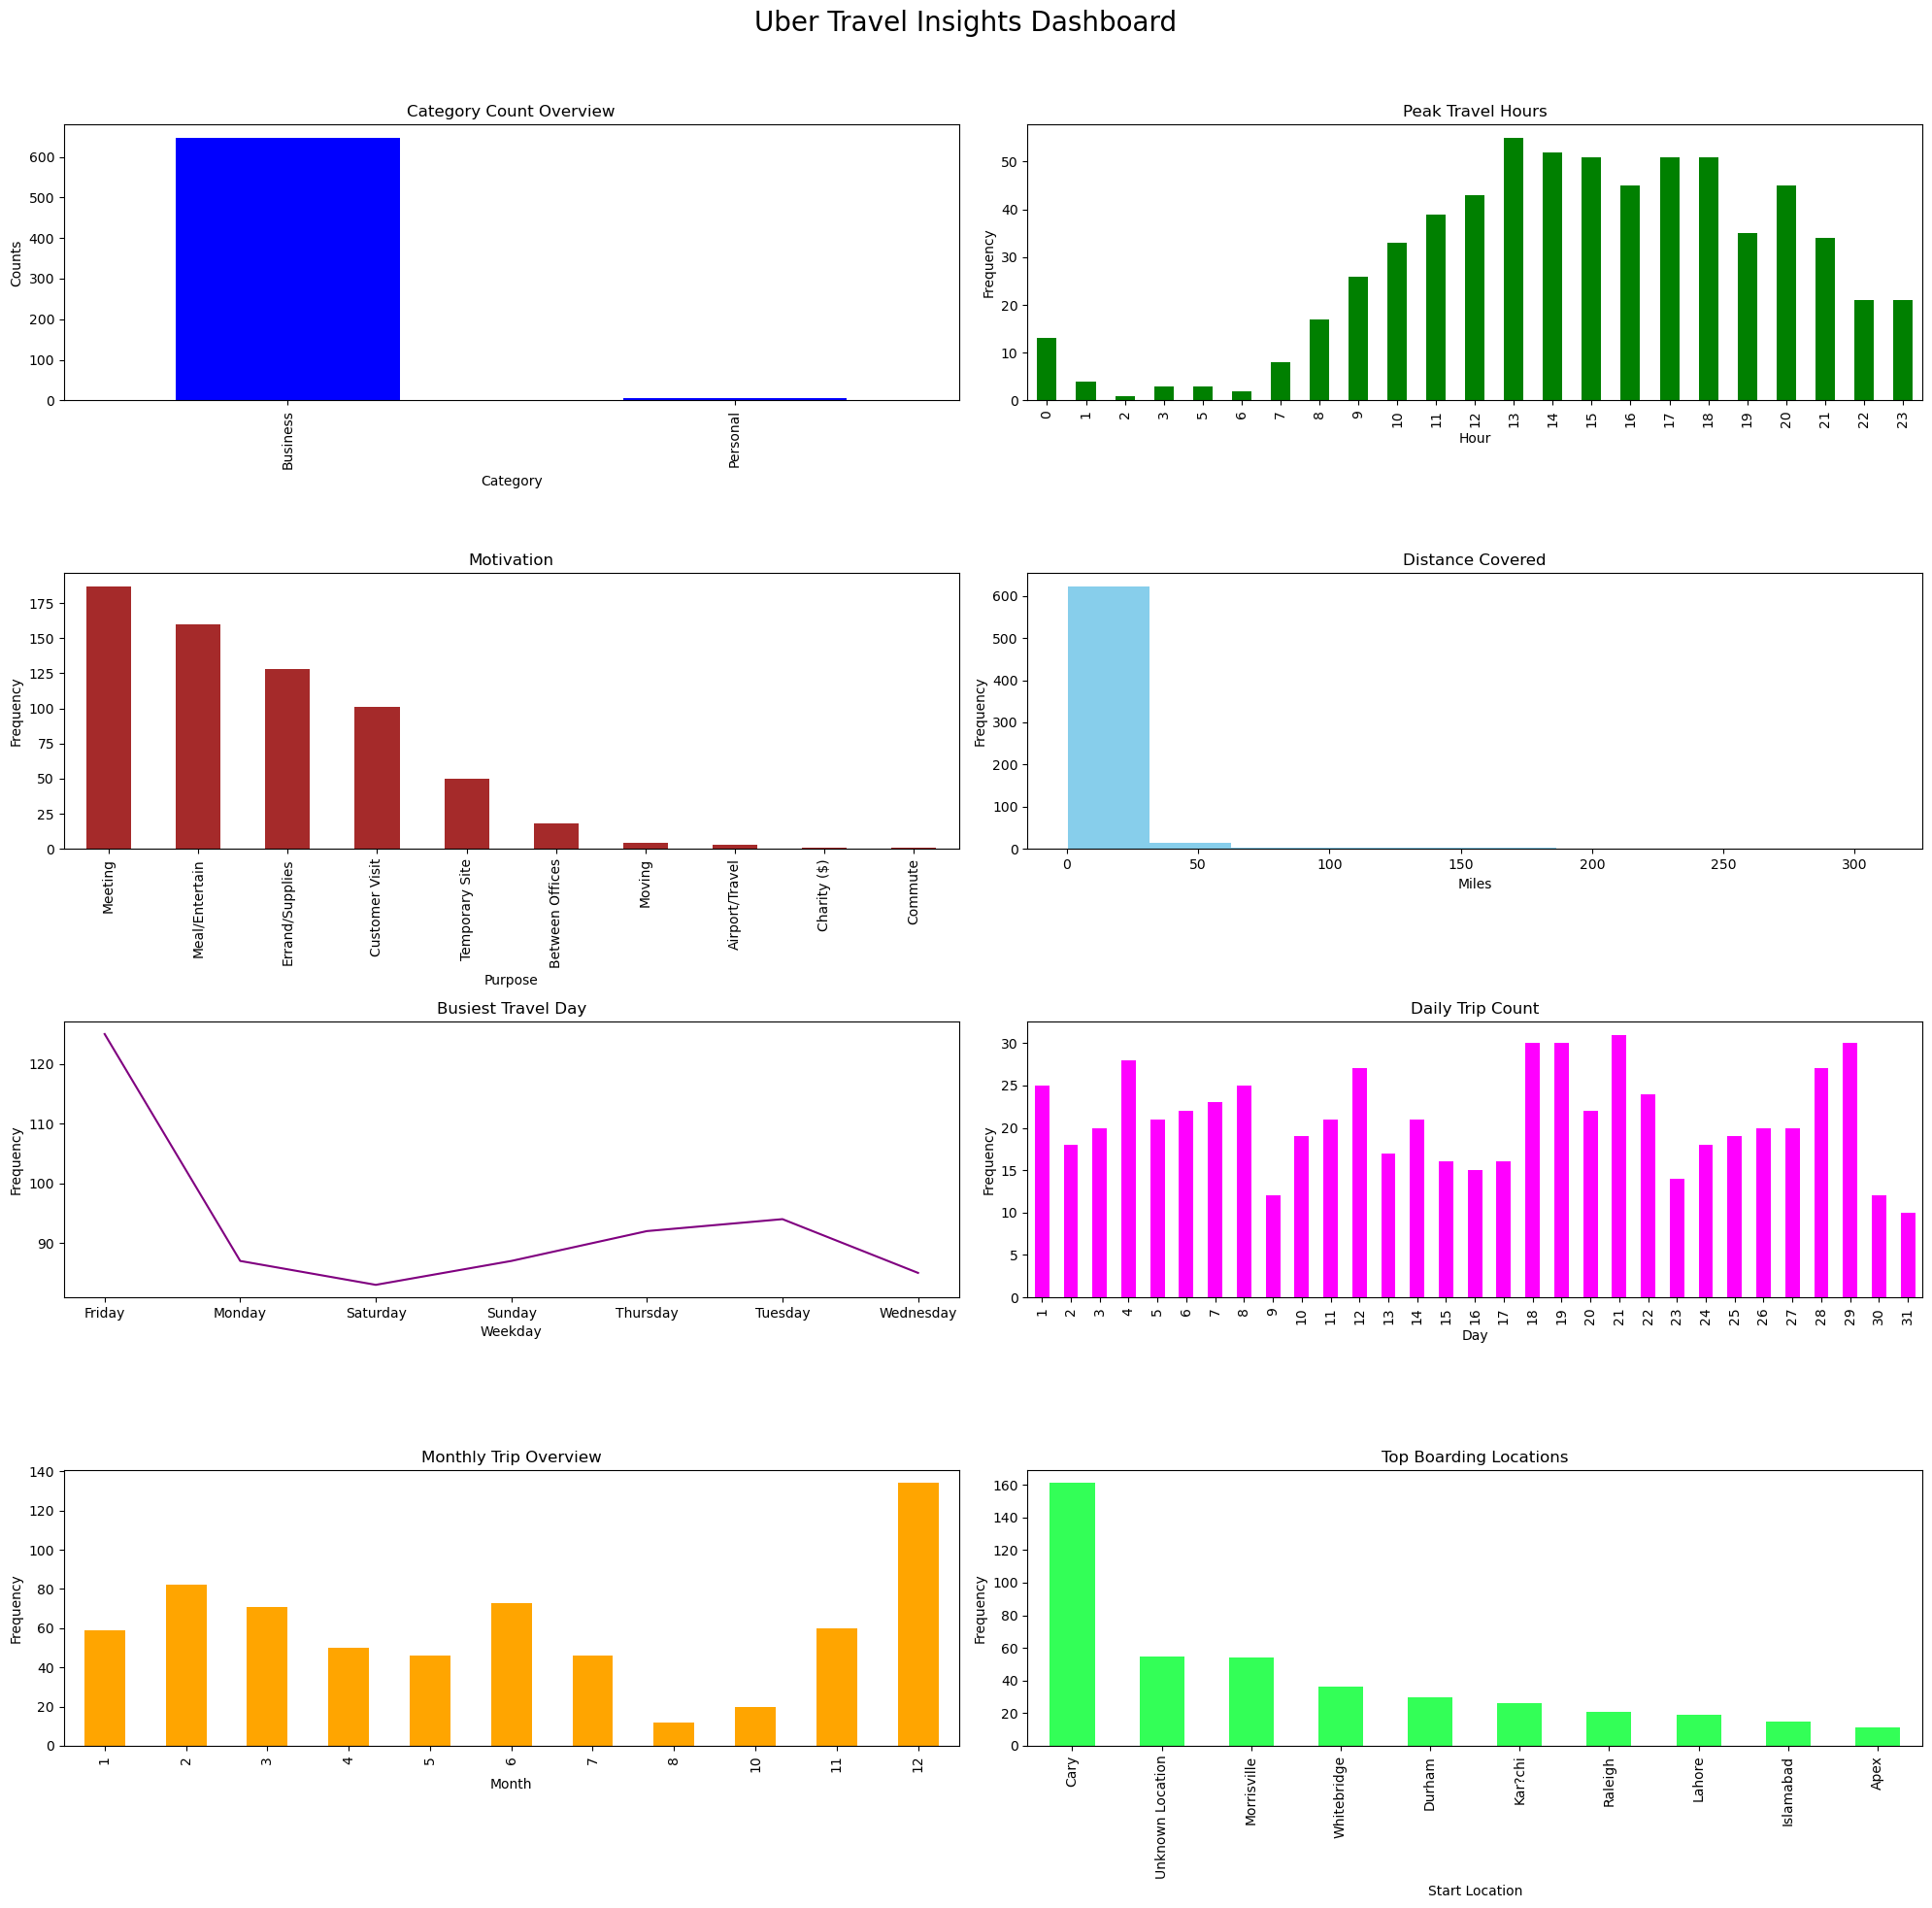

In [39]:
# Creating Python Dashboard

# Create subplots grid (4 rows, 2 columns)
fig, axes = plt.subplots(4, 2, figsize=(20, 20))  
fig.suptitle('Uber Travel Insights Dashboard', fontsize=20)

# Plot 1: Category Count Overview
data['CATEGORY*'].value_counts().plot(kind='bar', color='blue', ax=axes[0, 0])
axes[0, 0].set_xlabel('Category')
axes[0, 0].set_ylabel('Counts')
axes[0, 0].set_title("Category Count Overview")

# Plot 2: Peak Travel Hours
hours = data['START_DATE*'].dt.hour.value_counts().sort_index()  # Sort to ensure proper order
hours.plot(kind='bar', color='green', ax=axes[0, 1])
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Peak Travel Hours')

# Plot 3: Trip Purpose (Motivation)
data['PURPOSE*'].value_counts().plot(kind='bar', color='brown', ax=axes[1, 0])
axes[1, 0].set_xlabel('Purpose')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Motivation')

# Plot 4: Distance Covered (Miles)
data['MILES*'].plot(kind='hist', color='skyblue', ax=axes[1, 1])
axes[1, 1].set_xlabel('Miles')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title("Distance Covered")

# Plot 5: Busiest Travel Day
data['Week_day'].value_counts().sort_index().plot(kind='line', color='purple', ax=axes[2, 0])
axes[2, 0].set_xlabel('Weekday')
axes[2, 0].set_ylabel('Frequency')
axes[2, 0].set_title("Busiest Travel Day")

# Plot 6: Daily Trip Count
data['Day'].value_counts().sort_index().plot(kind='bar', color='magenta', ax=axes[2, 1])
axes[2, 1].set_xlabel('Day')
axes[2, 1].set_ylabel('Frequency')
axes[2, 1].set_title("Daily Trip Count")

# Plot 7: Monthly Trip Overview
data['Month'].value_counts().sort_index().plot(kind='bar', color='orange', ax=axes[3, 0])
axes[3, 0].set_xlabel('Month')
axes[3, 0].set_ylabel('Frequency')
axes[3, 0].set_title("Monthly Trip Overview")

# Plot 8: Top Boarding Location
data['START*'].value_counts().head(10).plot(kind='bar', color='#33FF57', ax=axes[3, 1])  # Show top 10 locations
axes[3, 1].set_xlabel('Start Location')
axes[3, 1].set_ylabel('Frequency')
axes[3, 1].set_title("Top Boarding Locations")

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.96])

fig.savefig('Uber-Dashboard')